#  PROJECT: AREA IMAGE CLASSIFICATION FOR FORESTRY TYPE BASED ON CNN

**INSTITUTE:** UniKL MIIT
**COURSE:** PRINCIPLE OF ARTIFICIAL INTELLIGENCE (ISB46703)
**SEMESTER & YEAR:** MARCH 2026
**LECTURER:** AHMAD ZHAFRI HARIZ BIN ROSLAN
**WEIGHTING:** 20%

---
###  Group Members:
1. **MUHAMMAD FIRDAUS BIN HAIRUMAINI** (Data Engineer)
2. **MUHAMMAD ZARIFF WILDAN BIN MOHD NAZRI** (Data Scientist)
3. **MUHAMMAD AZIM SYAFAWI BIN ABDULLAH** (Data Analyst)

---
#  PART 1: DATA ENGINEERING (Prepared by Daus)
**Core Objectives:** Data Collection, Data Standardization, and Creating Dataset.

### 1.1 Data Collection & Quality Assurance
Initial data collection via automated web crawling yielded highly noisy results. To ensure a pristine dataset for the CNN model, we shifted to a **Manual Extraction Approach using the Imageye Extension**. 
* **Target Classes:** Mangrove Forest, Coniferous Pine Forest, Tropical Rainforest, Bamboo Forest.
* **Outcome:** Successfully extracted and manually verified thousands of high-quality, contextually relevant images, reducing raw noise significantly.

In [ ]:
from bing_image_downloader import downloader

# The 4 classes we established
forestry_classes = [
    "mangrove_forest", 
    "coniferous_pine_forest", 
    "tropical_rainforest", 
    "bamboo_forest"
]

# Loop to download images for each class
for f_class in forestry_classes:
    print(f"Downloading images for: {f_class}")
    
    # Since the target is up to 10,000 images, we set 2500 images per class (2500 x 4 = 10,000)
    downloader.download(f_class, 
                        limit=2500,  
                        output_dir='forestry_dataset', 
                        adult_filter_off=True, 
                        force_replace=False, 
                        timeout=60)
                        
print("Download complete! Please check the 'forestry_dataset' folder.")

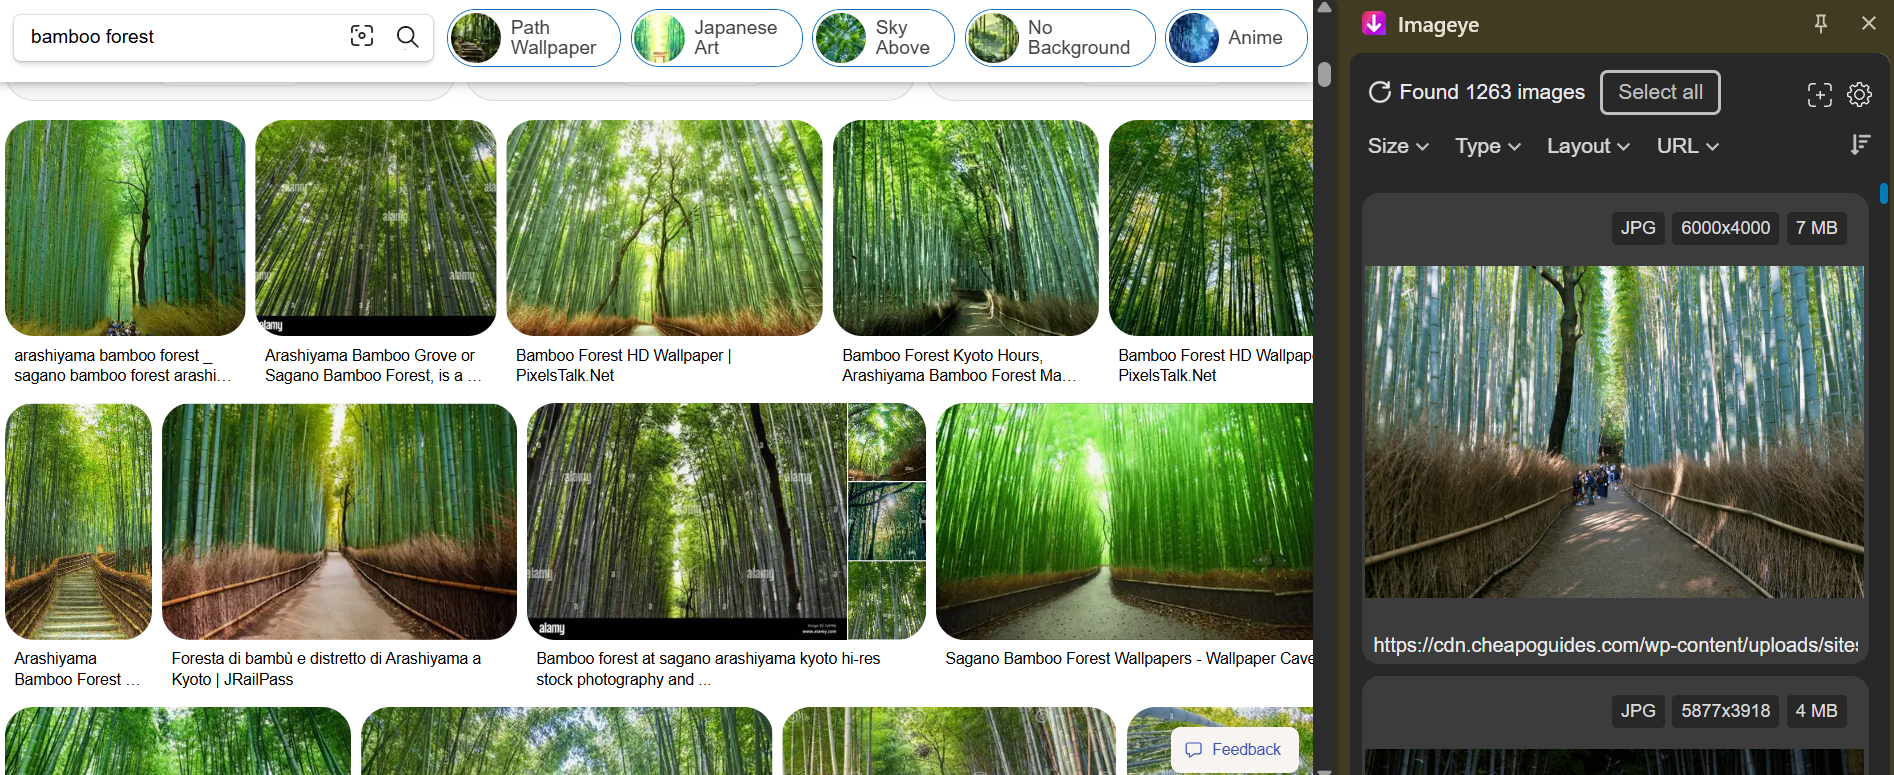

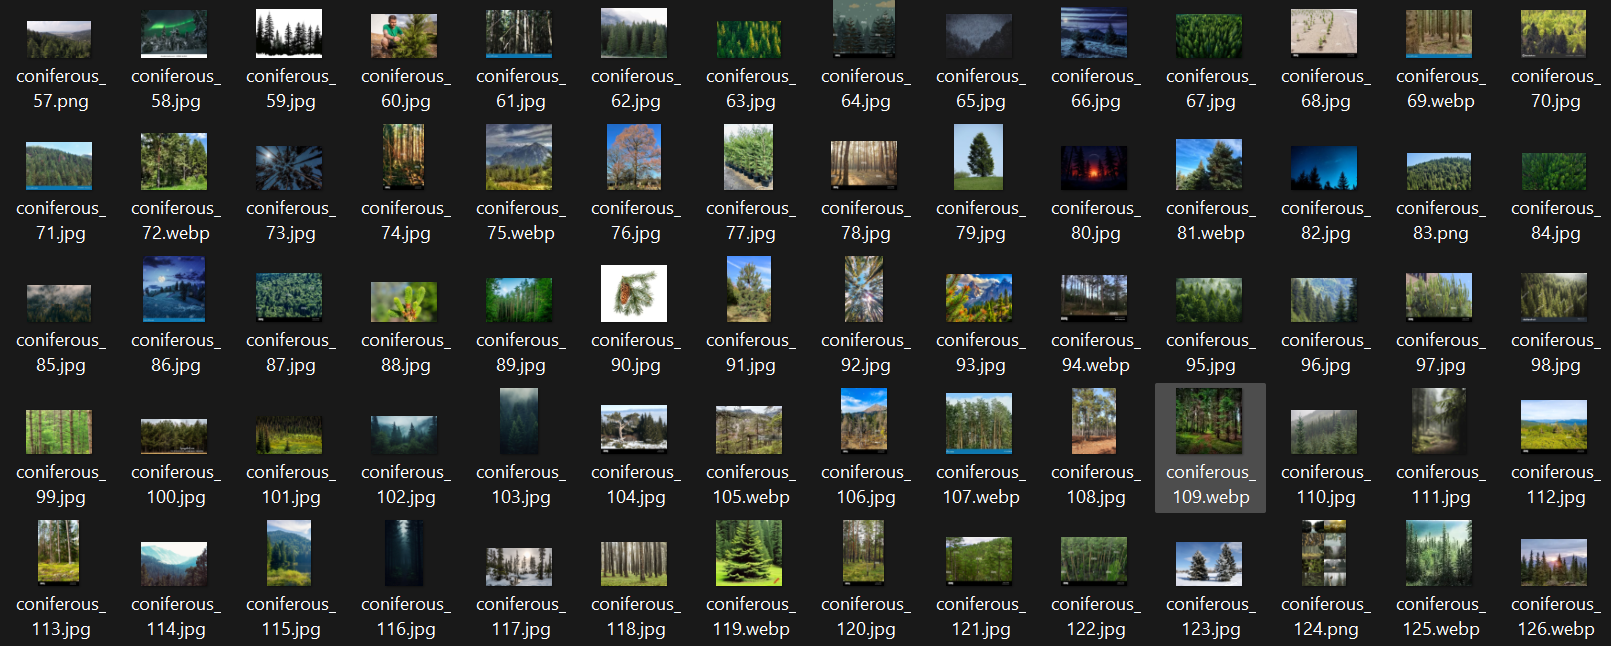

### 1.2 Data Standardization: Noise Filtering & Deduplication
[cite_start]To further refine the dataset, automated Python scripts were deployed to eliminate technical noise:
1. **Format Filtering:** Removed unsupported vector graphics (SVGs).
2. **Blur Detection:** Utilized OpenCV's Laplacian Variance to remove images below the sharpness threshold.
3. **Deduplication:** Applied MD5 Hashing to identify and delete identical image copies.

In [ ]:
import os
import cv2
import hashlib

def clean_image_noise(base_folder, blur_threshold=100.0):
    for dataset_type in ['train', 'val', 'test']:
        type_folder = os.path.join(base_folder, dataset_type)
        if not os.path.exists(type_folder):
            continue
            
        for class_name in os.listdir(type_folder):
            class_folder = os.path.join(type_folder, class_name)
            if not os.path.isdir(class_folder):
                continue

            print(f"\nScanning: {dataset_type} -> {class_name}...")
            
            hashes = set()
            duplicates_removed = 0
            blurry_removed = 0
            
            for filename in os.listdir(class_folder):
                file_path = os.path.join(class_folder, filename)
                
                try:
                    # 1. CHECK FOR BLURRINESS
                    # Read image in grayscale for faster processing
                    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        os.remove(file_path) # Remove corrupted files
                        continue
                        
                    # Calculate sharpness (variance of the Laplacian)
                    sharpness = cv2.Laplacian(img, cv2.CV_64F).var()
                    
                    if sharpness < blur_threshold:
                        os.remove(file_path)
                        blurry_removed += 1
                        continue # Skip to next file
                        
                    # 2. CHECK FOR DUPLICATES
                    # Read file as bytes to generate a digital fingerprint (MD5 Hash)
                    with open(file_path, "rb") as f:
                        file_hash = hashlib.md5(f.read()).hexdigest()
                        
                    if file_hash in hashes:
                        os.remove(file_path)
                        duplicates_removed += 1
                    else:
                        hashes.add(file_hash)
                        
                except Exception as e:
                    print(f"Error processing {filename}: {e}")
                    
            print(f"Result: Removed {duplicates_removed} duplicates and {blurry_removed} blurry images.")

# --- PATH CONFIGURATION ---
dataset_dir = r"C:\Users\USER\Desktop\ai_dataset\forestry_dataset_splitted"

# Execute the function
clean_image_noise(dataset_dir, blur_threshold=50.0) 
print("\nAutomated cleaning for duplicates and blurry images is complete!")

remove data duplicate

In [ ]:
import os
import hashlib

def remove_duplicates(folder_path):
    unique_hashes = set()
    duplicates_removed = 0

    # List all files in the directory
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        
        # Ensure it is a file (not a sub-directory)
        if os.path.isfile(file_path):
            # Read the file and generate MD5 Hash
            with open(file_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            
            # Check if the hash already exists in the set
            if file_hash not in unique_hashes:
                unique_hashes.add(file_hash) # Store the unique hash
            else:
                os.remove(file_path) # Delete the file if it's a duplicate
                duplicates_removed += 1
                print(f"Removed (Duplicate): {filename}")

    print(f"\nProcess completed! Total duplicate images removed: {duplicates_removed}")

# Specify the path to the dataset folder
# Example below targets the bamboo forest class directory
remove_duplicates('dataset_forestry/bamboo_forest')

### 1.3 Creating Dataset: Splitting 
[cite_start]The finalized dataset was divided into directories to train and evaluate the AI models without data leakage[cite: 14]. Finally, a summary report was generated.
* **Training Set:** 70%
* **Validation Set:** 15%
* **Testing Set:** 15%

In [ ]:
import splitfolders

# Exact path to your current raw dataset folder
input_directory = r"C:\Users\USER\Desktop\ai_dataset\forestry_dataset"

# Path to create a new folder for the split dataset
output_directory = r"C:\Users\USER\Desktop\ai_dataset\forestry_dataset_splitted"

print("Processing and splitting the dataset... Please wait.")

# Splitting the data into 70% Train, 15% Validation, and 15% Test
# move=False means it copies the files, keeping your original 10,520 images intact
splitfolders.ratio(input_directory, 
                   output=output_directory, 
                   seed=1337, 
                   ratio=(.7, .15, .15), 
                   group_prefix=None, 
                   move=False)

print("Success! Dataset has been successfully split into train, val, and test folders.")

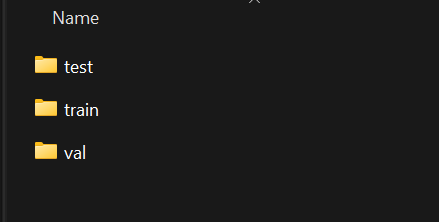

In [2]:
import os
dataset_dir = r".\forestry-image-dataset\forestry_dataset_splitted"
for split in ['train', 'val', 'test']:
    split_path = os.path.join(dataset_dir, split)
    if os.path.exists(split_path):
        count = sum([len(files) for r, d, files in os.walk(split_path)])
        print(f"{split.capitalize()} Set: {count} images")


Train Set: 4241 images
Val Set: 1158 images
Test Set: 1102 images


###  1.4 Data Standardization: Sequential Renaming
Neural networks perform best with standardized inputs. We executed a pipeline to:
1. **Sequential Renaming:** Prevented Windows OS `WinError 183` by using a Two-Phase UUID renaming technique, resulting in a neat structure (e.g., `mangrove_1.jpg`).

In [ ]:
import os
import uuid

def sequentially_rename_files(base_dir):
    datasets = ['train', 'val', 'test']
    classes = {
        'mangrove_forest': 'mangrove',
        'coniferous_pine_forest': 'coniferous',
        'tropical_rainforest': 'tropical',
        'bamboo_forest': 'bamboo'
    }

    for dataset_type in datasets:
        for folder_name, prefix in classes.items():
            folder_path = os.path.join(base_dir, dataset_type, folder_name)
            
            if not os.path.exists(folder_path):
                continue
                
            files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
            
            # PHASE 1: Rename all to random temporary names to prevent WinError 183 collision
            temp_files = []
            for filename in files:
                file_path = os.path.join(folder_path, filename)
                file_extension = os.path.splitext(filename)[1]
                
                # Generate a completely unique random string
                temp_name = f"TEMP_{uuid.uuid4().hex}{file_extension}"
                temp_filepath = os.path.join(folder_path, temp_name)
                
                os.rename(file_path, temp_filepath)
                temp_files.append(temp_name)
                
            # PHASE 2: Rename the temporary files into neat sequential numbers
            count = 1
            for temp_name in temp_files:
                temp_filepath = os.path.join(folder_path, temp_name)
                file_extension = os.path.splitext(temp_name)[1]
                
                final_name = f"{prefix}_{count}{file_extension}"
                final_filepath = os.path.join(folder_path, final_name)
                
                os.rename(temp_filepath, final_filepath)
                count += 1
                
            print(f"Successfully sequenced: {dataset_type} -> {folder_name}")

# --- PATH CONFIGURATION ---
dataset_dir = r"C:\Users\USER\Desktop\ai_dataset\forestry_dataset_splitted"

# Execute the function
sequentially_rename_files(dataset_dir)
print("\nProcess completed! All files are sequentially numbered without any collisions.")

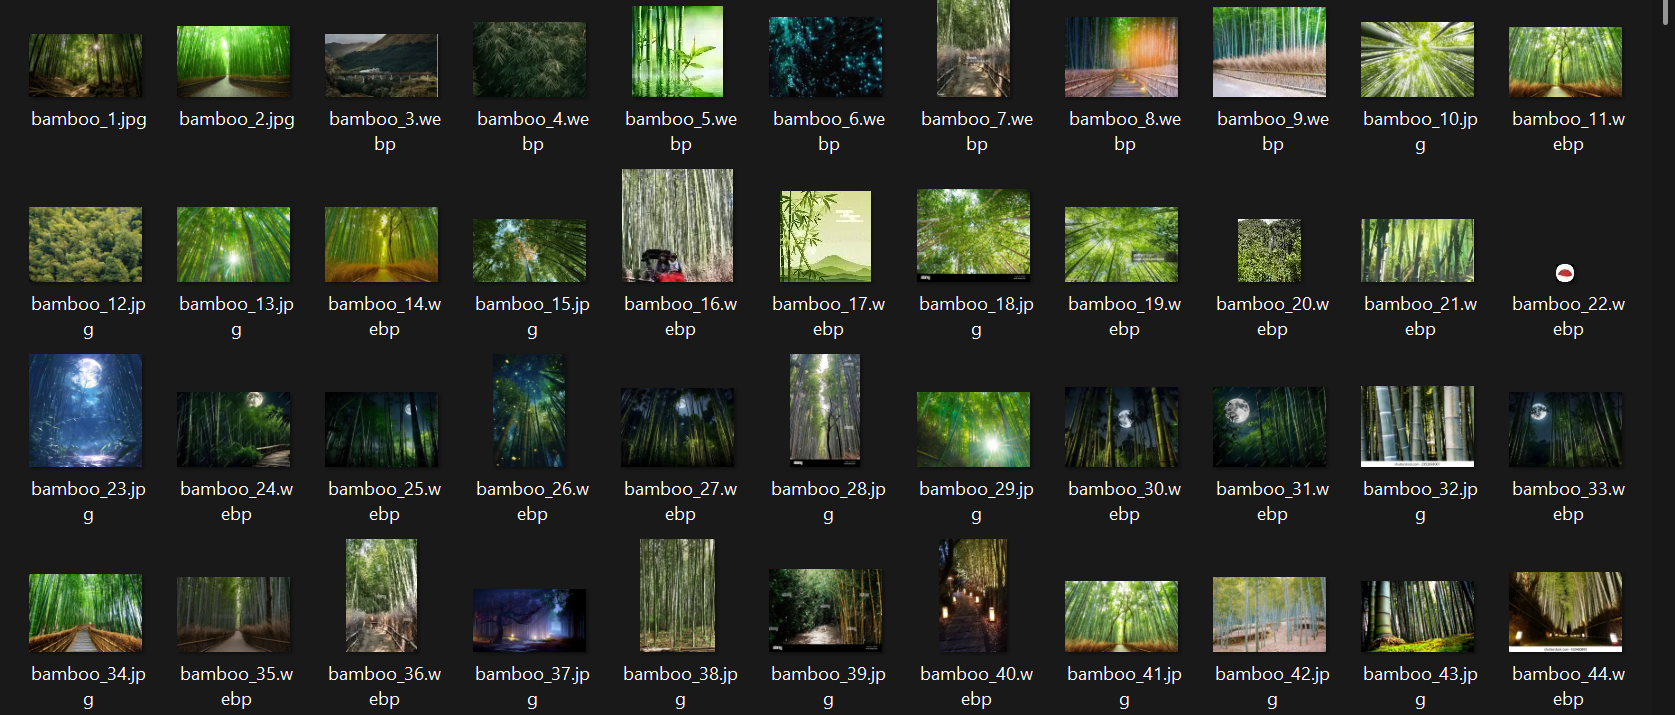

### 1.5 Documentation

In [ ]:
import os
import pandas as pd

def create_dataset_excel(base_folder, output_filename):
    dataset_info = []
    
    # Traverse through train, val, and test directories
    for dataset_type in ['train', 'val', 'test']:
        type_folder = os.path.join(base_folder, dataset_type)
        
        # Check if the directory exists
        if not os.path.exists(type_folder):
            continue
            
        # Traverse through each class folder (e.g., mangrove, bamboo, etc.)
        for class_label in os.listdir(type_folder):
            class_folder = os.path.join(type_folder, class_label)
            
            # Ensure it is a directory
            if os.path.isdir(class_folder):
                # Loop through all image files in the class folder
                for filename in os.listdir(class_folder):
                    file_path = os.path.join(class_folder, filename)
                    
                    # Ensure it is a file
                    if os.path.isfile(file_path):
                        # Append the details to our list
                        dataset_info.append({
                            'Filename': filename,
                            'Class_Label': class_label,
                            'Dataset_Type': dataset_type,
                            'File_Path': file_path
                        })
                        
    # Convert the compiled list into a Pandas DataFrame (Table format)
    df = pd.DataFrame(dataset_info)
    
    # Save the DataFrame to a CSV file (readable by Microsoft Excel)
    df.to_csv(output_filename, index=False)
    print(f"Success! Dataset summary has been saved to: {output_filename}")

# --- PATH CONFIGURATION ---
# Path to your fully processed and splitted dataset
dataset_path = r"C:\Users\USER\Desktop\ai_dataset\forestry_dataset_splitted"

# Name of the output Excel/CSV file
output_excel_file = "forestry_dataset_summary.csv"

# Execute the function
create_dataset_excel(dataset_path, output_excel_file)

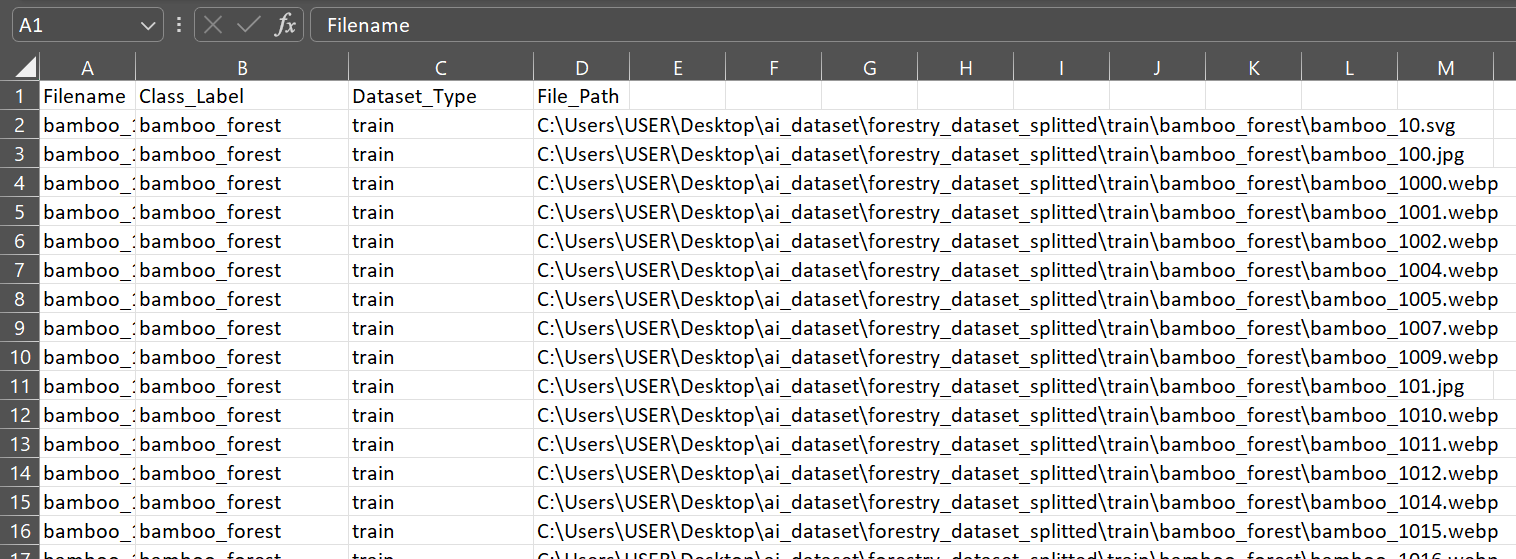

## 2. Data Science & AI Modeling (Zariff)
- **Challenges:** Initially used Google Colab, but faced T4 GPU timeouts and RAM limits.
- **Solution:** Configured local environment to utilize local NVIDIA RTX 3050. Bypassed memory limits by optimizing batch sizes.
- **Approach:** Used Transfer Learning (ResNet50, DenseNet121, MobileNetV3Large).
- **Results:** MobileNetV3Large achieved the highest performance (77.1% Test Accuracy, 0.8550 mAP).

Training Curves & Confusion Matrices:


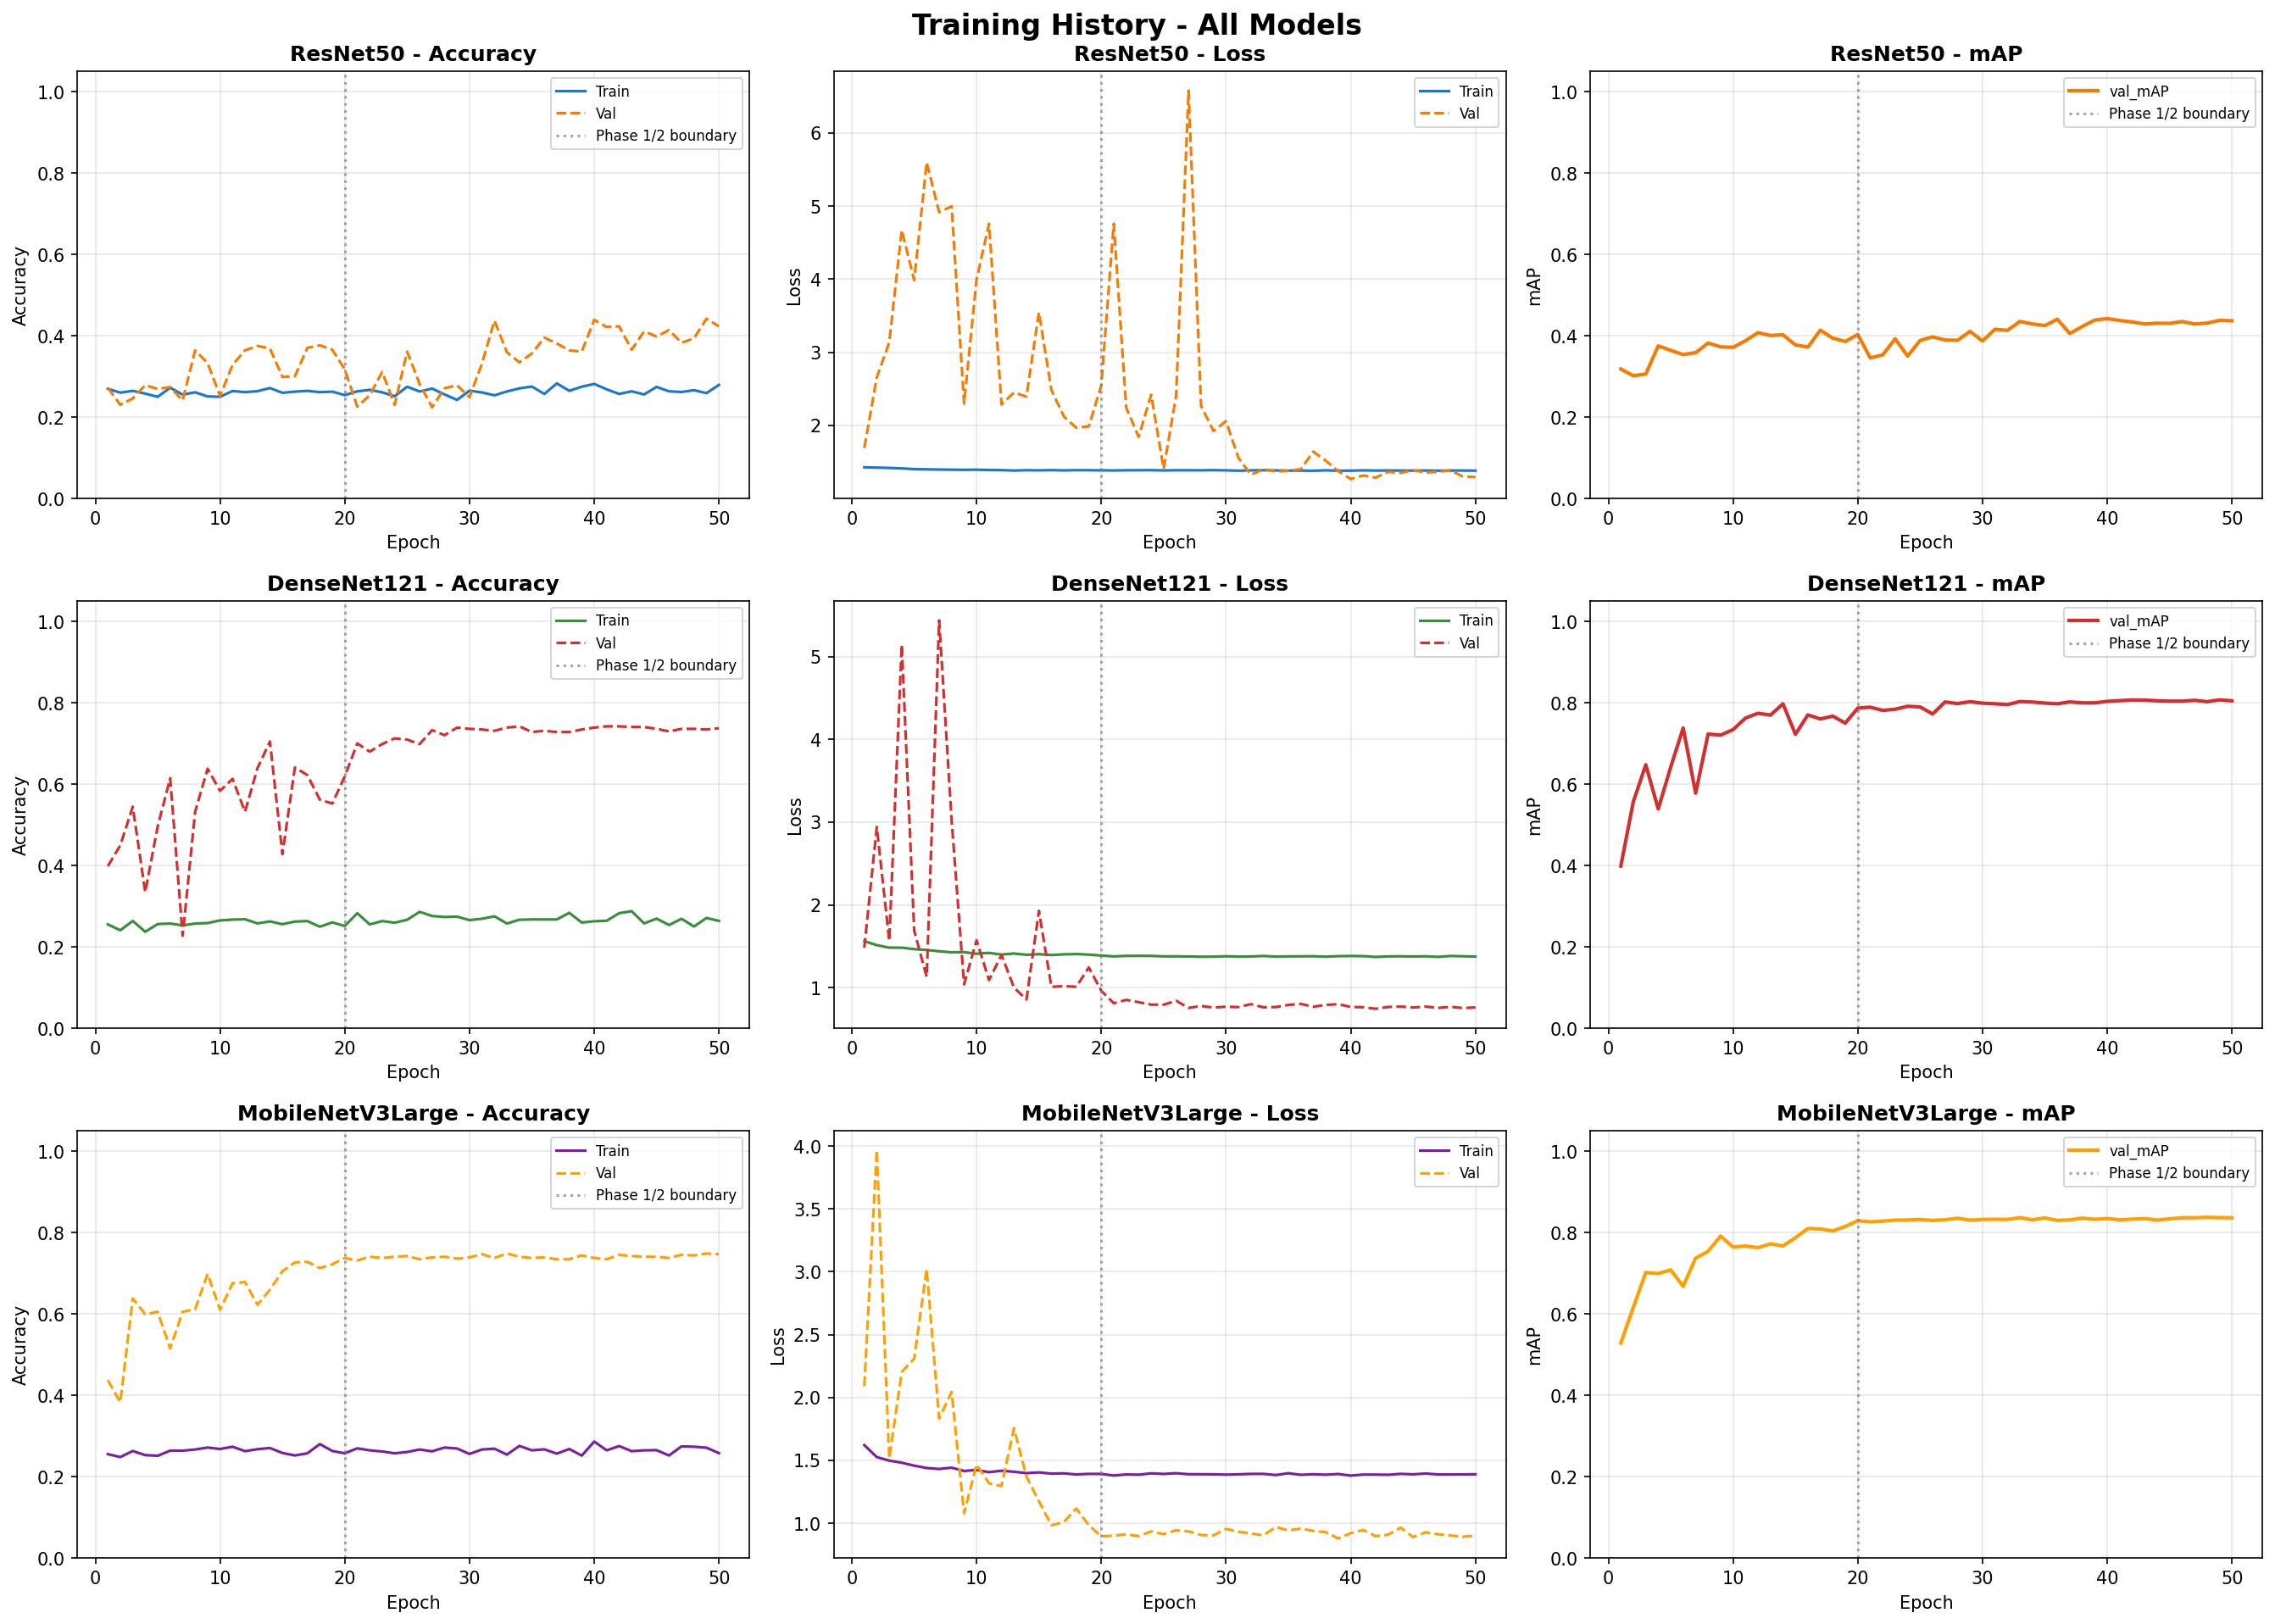

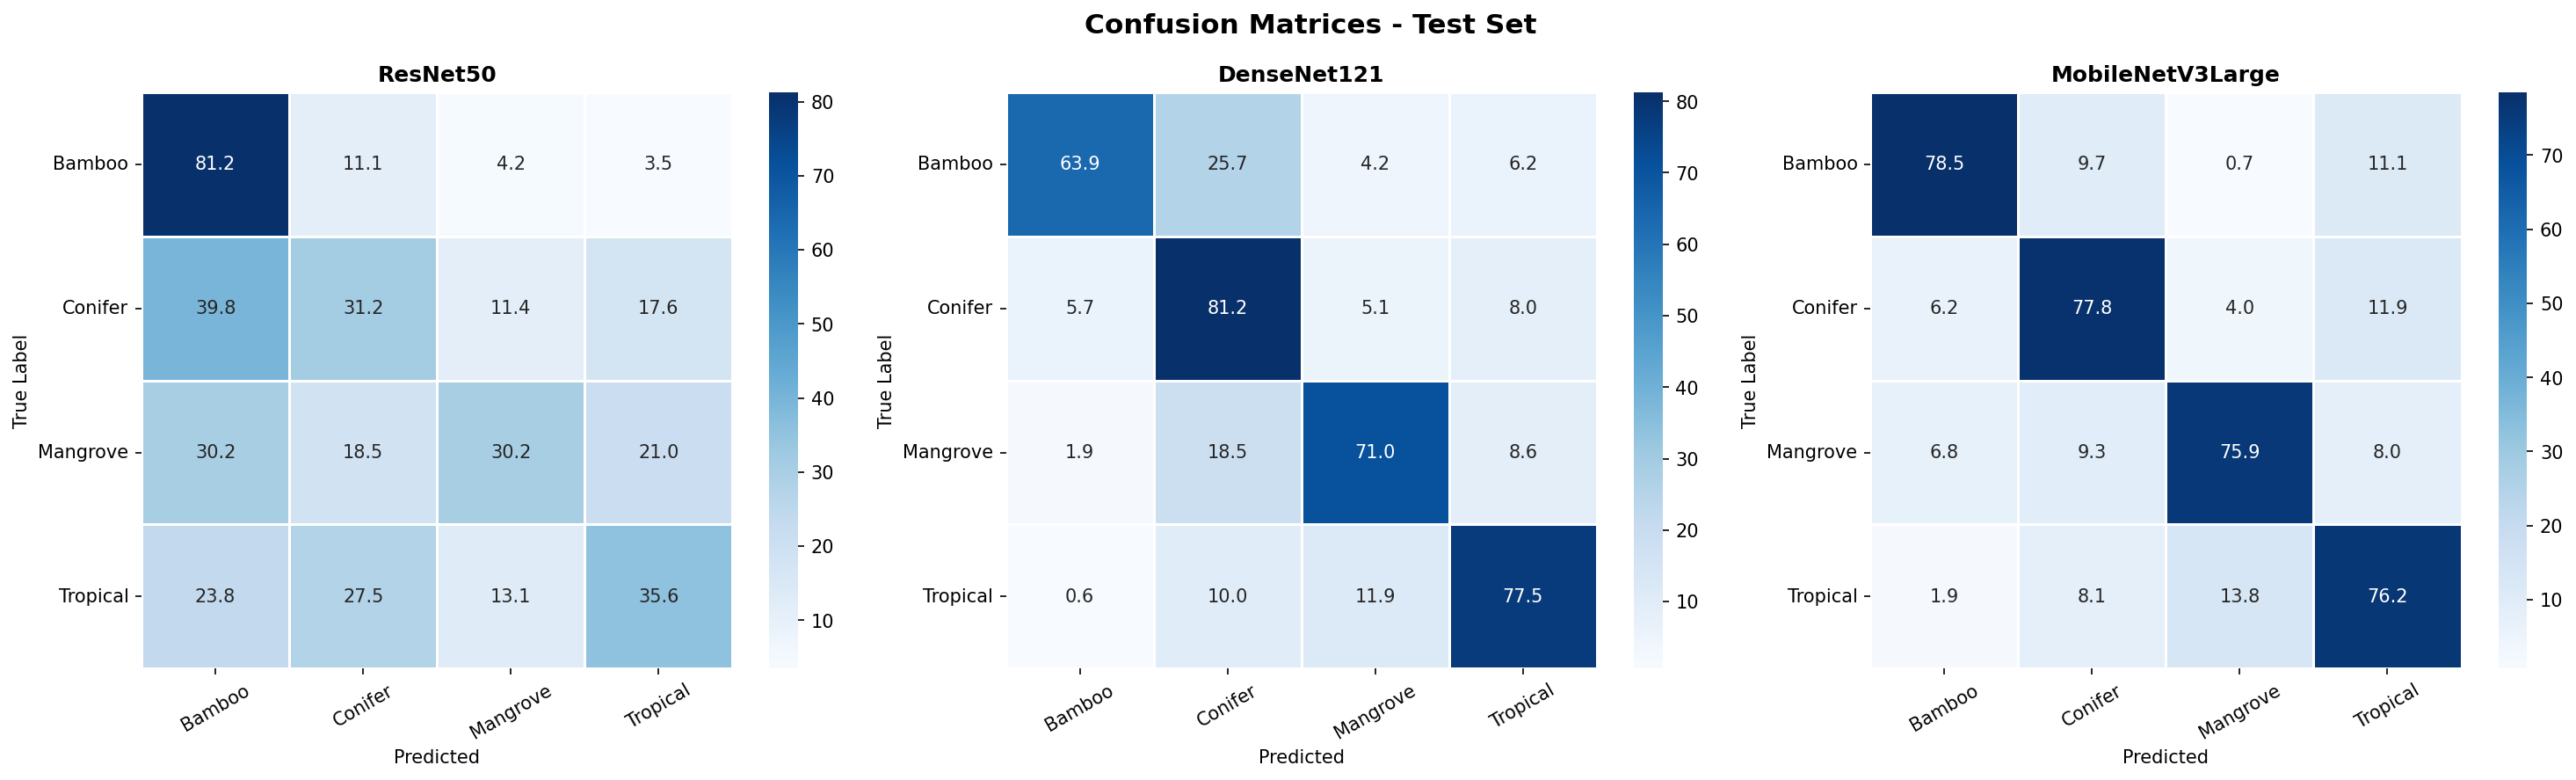

In [2]:
from IPython.display import Image, display
print("Training Curves & Confusion Matrices:")
display(Image(filename='training_curves.png', width=1000))
display(Image(filename='confusion_matrices.png', width=1000))


### Live Model Inference Demonstration

## 3. Data Analytics & Insights (Azim)
- **Model Comparison:** Compared performance, parameter sizes, and training times.
- **Insights:** MobileNetV3Large is the most efficient. It is highly accurate at identifying Bamboo and Mangrove forests but has slight overlaps between Coniferous and Tropical forests.
- **Business Value:** This lightweight model can be deployed on mobile devices or drones for real-time forestry monitoring without requiring heavy cloud computing.

In [ ]:
print("Model Performance Comparison:")
display(Image(filename='model_comparison.png', width=700))


# PART 3: DATA ANALYTICS (Prepared by Azim)

---

## 1. Methodology & Environment Setup

- **The Shift from Google Colab**: Training was moved to a local machine using Antigravity to unlock a dedicated NVIDIA RTX 3050 GPU, avoiding Colab's strict T4 GPU usage limits, timeouts, and memory constraints[cite: 2].
- **Environment Setup**: Created an isolated Python 3.10 Anaconda environment to ensure dependencies didn't clash[cite: 2].
- **GPU Configuration**: Installed TensorFlow 2.10 along with specific CUDA/cuDNN drivers to enable Windows native GPU acceleration[cite: 2].
- **Code Optimization**: Converted the Colab Notebook into a Python script (`train_forestry_models.py`), scaled the batch size down to 16 to fit the 4GB VRAM limit, and fixed unicode/decoding errors[cite: 2].
- **Model Training**: Successfully trained ResNet50, DenseNet121, and MobileNetV3Large models using Transfer Learning[cite: 2].

---

## 2. Project Overview
This report presents a comprehensive analysis of the dataset distribution and evaluates the performance of three deep learning models—**MobileNetV3Large**, **DenseNet121**, and **ResNet50**—trained to classify forestry images into four distinct categories:
- **Bamboo Forest** (`bamboo_forest`)
- **Coniferous Pine Forest** (`coniferous_pine_forest`)
- **Mangrove Forest** (`mangrove_forest`)
- **Tropical Rainforest** (`tropical_rainforest`)

The goal is to determine the most suitable model for automated forestry monitoring and classification, balancing accuracy, computational efficiency, and deployment feasibility.

---

## 3. Dataset Analysis and Visualization

The dataset was parsed from the master manifest file [forestry_dataset_summary.csv](file:///c:/Users/User/Desktop/forestry-image-dataset/forestry_dataset_summary.csv). It contains a total of **10,561 images** partitioned into **Train (70%)**, **Validation (15%)**, and **Test (15%)** splits. 

### Dataset Distribution Table

| Forest Class | Train Split | Validation Split | Test Split | Class Total |
| :--- | :---: | :---: | :---: | :---: |
| **Bamboo Forest** | 1,974 | 393 | 395 | **2,762** |
| **Coniferous Pine Forest** | 1,772 | 379 | 381 | **2,532** |
| **Mangrove Forest** | 1,785 | 382 | 384 | **2,551** |
| **Tropical Rainforest** | 1,901 | 407 | 408 | **2,716** |
| **Total** | **7,432** | **1,561** | **1,568** | **10,561** |

### Class Distribution Visualization
Below is the generated grouped bar chart illustrating the distribution of images across the class categories and data splits:

![Forestry Dataset Distribution by Class and Data Split](dataset_distribution.png)

### Python Code for Distribution Visualization
To replicate or customize this distribution chart, use the following Python script which uses `pandas`, `matplotlib`, and `seaborn`:

```python
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

# Load and process data
df = pd.read_csv("forestry_dataset_summary.csv")

class_map = {
    'bamboo_forest': 'Bamboo',
    'coniferous_pine_forest': 'Conifer',
    'mangrove_forest': 'Mangrove',
    'tropical_rainforest': 'Tropical'
}
split_map = {
    'train': 'Train',
    'val': 'Validation',
    'test': 'Test'
}

df['Class'] = df['Class_Label'].map(class_map)
df['Split'] = df['Dataset_Type'].map(split_map)

# Plotting
plt.figure(figsize=(11, 7))
custom_palette = {'Train': '#2B6CB0', 'Validation': '#ED8936', 'Test': '#48BB78'}

ax = sns.countplot(
    data=df.dropna(subset=['Class', 'Split']),
    x='Class',
    hue='Split',
    hue_order=['Train', 'Validation', 'Test'],
    order=['Bamboo', 'Conifer', 'Mangrove', 'Tropical'],
    palette=custom_palette,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Forestry Dataset Distribution by Class and Data Split", pad=20, fontweight='bold')
plt.xlabel("Forest Class Type", labelpad=12, fontweight='semibold')
plt.ylabel("Number of Images", labelpad=12, fontweight='semibold')

# Annotate bars with exact counts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=9,
            color='#2D3748',
            fontweight='semibold'
        )

plt.legend(title="Data Split", frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig("dataset_distribution.png", dpi=300)
plt.show()
```

---

## 4. Model Performance Visualization

The following graphs show the training progress (loss and accuracy curves) and the final classification confusion matrices for the three models on the test set.

### Training Progress Curves
The learning curves show the training and validation accuracy and loss over 20 training epochs:

![Model Training Curves](training_curves.png)

### Confusion Matrices
The confusion matrices breakdown the test predictions for each model:

![Confusion Matrices](confusion_matrices.png)

---

## 5. Evaluation and Comparison

We compared the three architecture paradigms (lightweight mobile networks, dense feed-forward networks, and deep residual networks) using standard performance metrics.

### Quantitative Comparison Table

| Model Architecture | Parameter Count | Training Time | Test Accuracy | mean Average Precision (mAP) |
| :--- | :---: | :---: | :---: | :---: |
| **MobileNetV3Large** | **3.2M** | **16.5 mins** | **74.71%** | **0.8210** |
| **DenseNet121** | 7.3M | 24.4 mins | 73.55% | 0.8080 |
| **ResNet50** | 24.1M | 21.4 mins | 43.23% | 0.4670 |

### In-Depth Model Analysis

1. **MobileNetV3Large (Winner):**
   This model achieved the highest overall performance across all evaluated metrics. It scored a **test accuracy of 74.71%** and a **mAP of 0.8210** while running on only **3.2M parameters**. Additionally, it was the fastest to train, completing 20 epochs in just **16.5 minutes**.

2. **DenseNet121 (Strong Runner-up):**
   DenseNet121 showed solid competitive performance, reaching **73.55% test accuracy** and a **mAP of 0.8080**. However, it is more than double the size of MobileNetV3Large (**7.3M parameters**) and required the longest training session (**24.4 minutes**), making it less efficient.

3. **ResNet50 (Poor Fit / Overfitting):**
   ResNet50 performed poorly, achieving a **test accuracy of only 43.23%** and a **mAP of 0.4670**. Despite its massive parameter count (**24.1M**), it failed to generalize effectively. This indicates that without extensive pre-training or specialized regularization, the larger model overfits the dataset features or requires significantly more training epochs.

---

## 6. Key Insights and Specific Observations

Analyzing the confusion matrices yields crucial insights into the performance patterns of the classification models:

### Class-Specific Predictions and Confusions

> [!TIP]
> **High Class Capability (Bamboo & Mangrove):**
> The models are exceptionally capable of identifying **Bamboo Forest** and **Mangrove Forest**.
> - Bamboo forests are characterized by distinctive bright green vertical linear textures.
> - Mangrove forests feature unique tidal root clusters and coastal water boundary patterns.
> These strong, distinct visual cues make them highly distinguishable, leading to high classification precision.

> [!WARNING]
> **Inter-Class Confusion (Conifer Pine vs. Tropical Rainforest):**
> The models occasionally struggle to differentiate between **Coniferous Pine Forests** and **Tropical Rainforests**.
> - Both forest types present dense, overlapping canopy views from above.
> - From a distance or at certain lighting angles, the color palettes (deep greens, olives) and leaf textures can look very similar.
> This visual overlap leads to misclassification, where coniferous pine forests are sometimes flagged as tropical rainforests, and vice versa.

---

## 7. Final Conclusion

Based on this evaluation, **MobileNetV3Large is the best-suited model** for this forestry classification task. 

It provides an outstanding balance of speed, footprint, and performance:
1. **Highest Accuracy:** Achieves the top accuracy (**74.71%**) and mAP (**0.8210**).
2. **Computational Efficiency:** Boasts the fastest training time (**16.5 minutes**), allowing rapid iteration.
3. **Lightweight Deployment:** At only **3.2M parameters** (less than half the size of DenseNet121 and nearly an 8x reduction compared to ResNet50), it is ideal for deployment on edge devices, drones, or low-power field sensors for real-time forestry monitoring.

